# 01 — Exploratory Data Analysis

Olist Brazilian E-Commerce. First look at the data after the dbt staging + marts pipeline.

**Goals**
- Validate the ~3% repeat-purchase claim quantitatively.
- Confirm cohort right-censoring impact.
- Check distributions of features we'll use for the Fase 2 propensity model.
- Surface any data quirks beyond what we already know.

In [1]:
import sys
from pathlib import Path

# Make src/olist importable both as script and from Jupyter
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()
ROOT = HERE if HERE.name != "notebooks" else HERE.parent
sys.path.insert(0, str(ROOT / "src"))

# Non-interactive backend when run as a script
import matplotlib  # noqa: E402

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
import seaborn as sns  # noqa: E402

from olist.io import read_mart  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


INTERACTIVE = "ipykernel" in sys.modules


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    if not INTERACTIVE:
        plt.close(fig)

## Load the marts

In [2]:
fct = read_mart("fct_orders")
dim_cust = read_mart("dim_customers")
rfm = read_mart("customer_rfm")
cohorts = read_mart("customer_cohorts")
monthly = read_mart("monthly_revenue")

print(f"fct_orders:    {len(fct):>7,} rows")
print(f"dim_customers: {len(dim_cust):>7,} rows")
print(f"customer_rfm:  {len(rfm):>7,} rows")
print(f"cohorts:       {len(cohorts):>7,} rows")
print(f"monthly:       {len(monthly):>7,} rows")

fct_orders:     99,441 rows
dim_customers:  96,096 rows
customer_rfm:   94,990 rows
cohorts:           220 rows
monthly:            24 rows


## Repeat-purchase rate

In [3]:
total_customers = dim_cust["customer_unique_id"].nunique()
repeat_customers = int(dim_cust["is_repeat_buyer"].sum())
print(f"Unique customers (customer_unique_id): {total_customers:>7,}")
print(f"Customers with >1 order:               {repeat_customers:>7,}")
print(f"Repeat rate:                           {repeat_customers / total_customers:>7.2%}")

Unique customers (customer_unique_id):  96,096
Customers with >1 order:                 2,997
Repeat rate:                             3.12%


In [4]:
# Distribution of orders per customer
order_counts = dim_cust["total_orders"].value_counts().sort_index().head(15)
print("Orders per customer (top values):")
print(order_counts)

Orders per customer (top values):
total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


## Monthly revenue and order volume

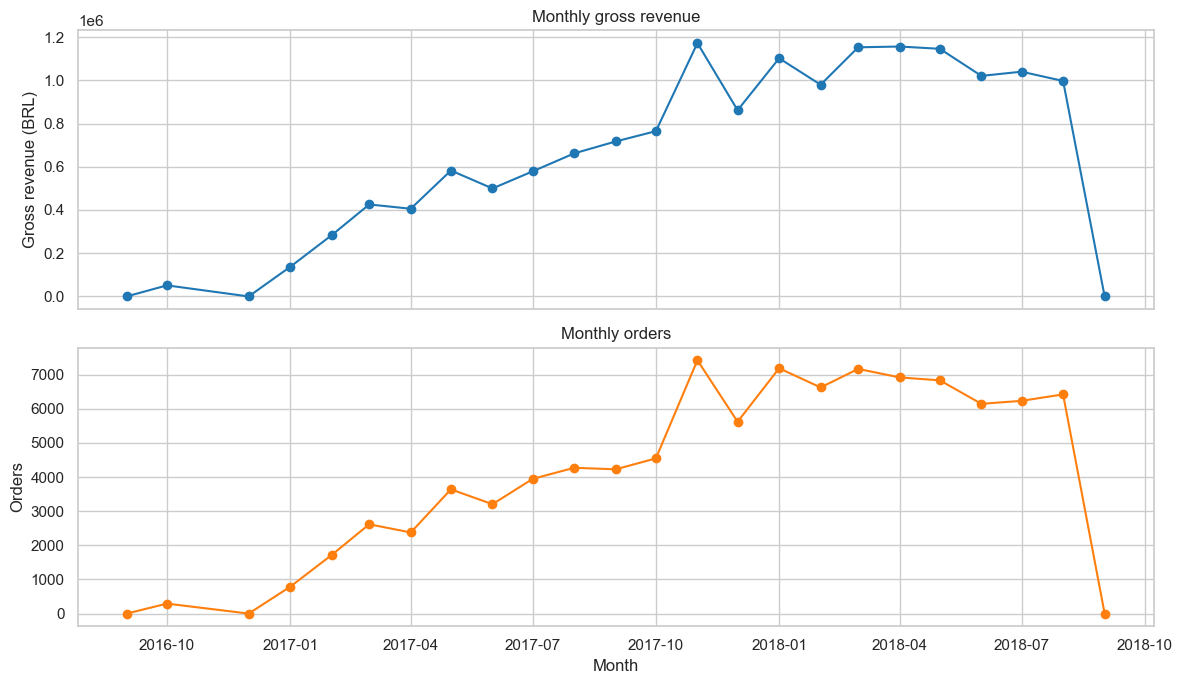

In [5]:
monthly["month"] = pd.to_datetime(monthly["month"])
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly["month"], monthly["gross_revenue"], marker="o", color="#1f77b4")
axes[0].set_ylabel("Gross revenue (BRL)")
axes[0].set_title("Monthly gross revenue")
axes[1].plot(monthly["month"], monthly["orders"], marker="o", color="#ff7f0e")
axes[1].set_ylabel("Orders")
axes[1].set_xlabel("Month")
axes[1].set_title("Monthly orders")
plt.tight_layout()
save(fig, "01_monthly_kpis")

**Notes.** Nov 2017 is the Black Friday spike. The sharp drop after Aug 2018 is at least partly right-censoring of orders that hadn't yet shipped/delivered when the dataset was extracted.

## Cohort retention

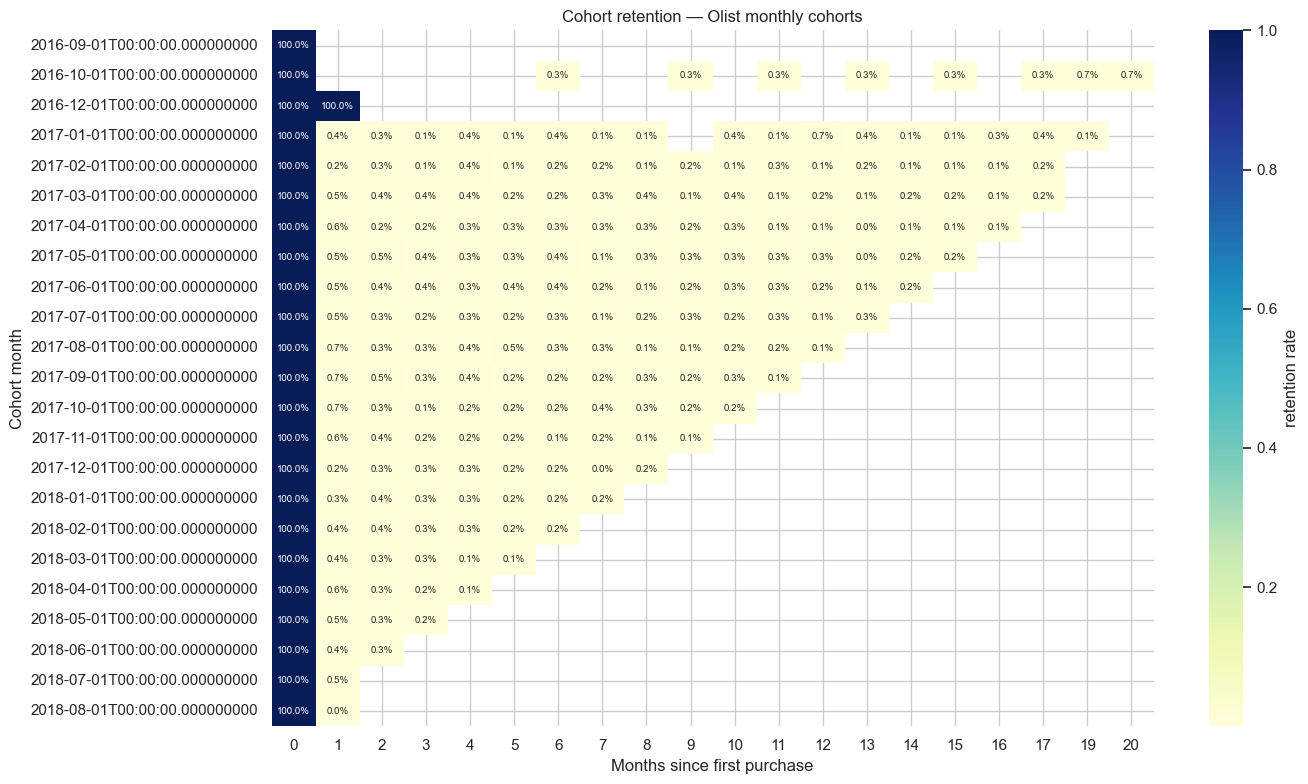

In [6]:
cohorts["cohort_month"] = pd.to_datetime(cohorts["cohort_month"])
pivot = cohorts.pivot(index="cohort_month", columns="months_since_first", values="retention_rate")

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
    ax=ax,
    cbar_kws={"label": "retention rate"},
    annot_kws={"size": 7},
)
ax.set_title("Cohort retention — Olist monthly cohorts")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Cohort month")
plt.tight_layout()
save(fig, "02_cohort_retention")

**Notes.** Diagonal NaNs grow as we approach the dataset end — that's right-censoring. Only compare retention at the same `months_since_first` value across cohorts.

## RFM segment distribution

In [7]:
seg_counts = rfm["rfm_segment_label"].value_counts()
print(seg_counts)
print(f"\nTotal customers segmented: {len(rfm):,}")

rfm_segment_label
At Risk      22697
Other        20711
Lost         15299
New          15115
Loyal        14633
Champions     6535
Name: count, dtype: int64

Total customers segmented: 94,990


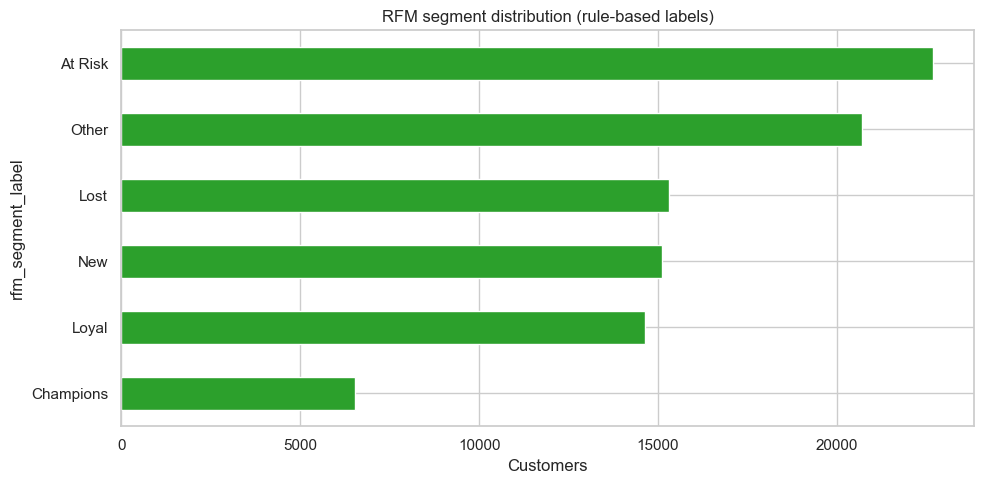

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
seg_counts.sort_values().plot.barh(ax=ax, color="#2ca02c")
ax.set_xlabel("Customers")
ax.set_title("RFM segment distribution (rule-based labels)")
plt.tight_layout()
save(fig, "03_rfm_segments")

**Note.** Frequency is dominated by F=1 (most customers buy once). 'Champions' / 'Loyal' / 'At Risk' segments are sparse, consistent with the ~3% repeat rate. Fase 2 will refine this with KMeans.

## Customer geographic distribution

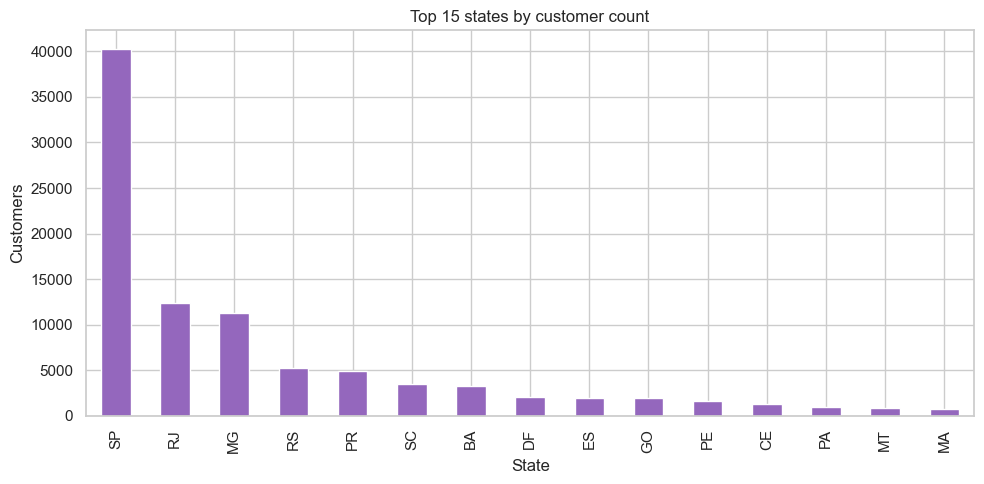

In [9]:
state_counts = dim_cust["state"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
state_counts.plot.bar(ax=ax, color="#9467bd")
ax.set_ylabel("Customers")
ax.set_xlabel("State")
ax.set_title("Top 15 states by customer count")
plt.tight_layout()
save(fig, "04_top_states")

SP (São Paulo) dominates by an order of magnitude — typical for Brazilian e-commerce.

## Delivery delays

In [10]:
delivered = fct[fct["delivery_days"].notna() & (fct["delivery_days"] >= 0)].copy()
late_subset = fct[fct["was_late"].notna()]
late_rate = late_subset["was_late"].sum() / len(late_subset)
print(f"Late delivery rate (among observed deliveries): {late_rate:.2%}")
print(f"Median delivery days: {delivered['delivery_days'].median():.0f}")
print(f"P90 delivery days:    {delivered['delivery_days'].quantile(0.9):.0f}")

Late delivery rate (among observed deliveries): 8.11%
Median delivery days: 10
P90 delivery days:    23


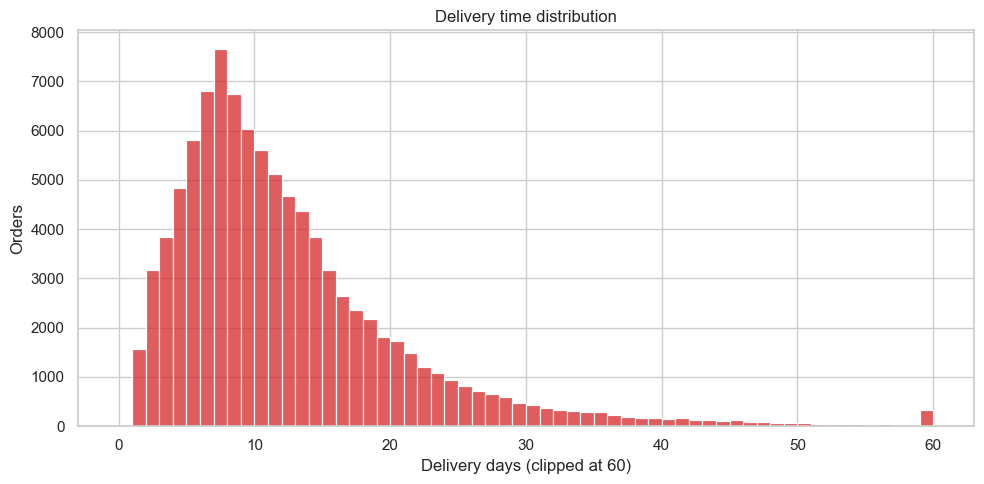

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(delivered["delivery_days"].clip(upper=60), bins=60, ax=ax, color="#d62728")
ax.set_xlabel("Delivery days (clipped at 60)")
ax.set_ylabel("Orders")
ax.set_title("Delivery time distribution")
plt.tight_layout()
save(fig, "05_delivery_days")

## First-order features by eventual repeat status

This is a preview of the signal we hope to learn in the Fase 2 propensity model:
what's different about the first order of a customer who *did* come back?

In [12]:
first_order = (
    fct.sort_values(["customer_unique_id", "purchased_at"])
    .groupby("customer_unique_id", as_index=False)
    .first()
)
first_order = first_order.merge(
    dim_cust[["customer_unique_id", "is_repeat_buyer"]], on="customer_unique_id"
)

cols = [
    "items_total",
    "delivery_days",
    "avg_review_score",
    "max_installments",
    "item_count",
    "unique_products",
]
preview = first_order.groupby("is_repeat_buyer")[cols].mean().T
preview.columns = ["one_time", "repeat"]
preview["repeat_minus_onetime"] = preview["repeat"] - preview["one_time"]
print("Mean of first-order features by repeat status:")
print(preview.round(2))

Mean of first-order features by repeat status:
                  one_time  repeat  repeat_minus_onetime
items_total         161.43  148.27                -13.16
delivery_days        12.11   11.95                 -0.16
avg_review_score      4.08    4.11                  0.02
max_installments      2.91    3.32                  0.41
item_count            1.14    1.22                  0.08
unique_products       1.04    1.07                  0.03


**Observation.** Repeat buyers tend to have slightly higher review scores, more items, and shorter delivery times. The signal is small (~3% positive class), which is exactly the modeling challenge — we'll evaluate it with PR-AUC and recall@top-decile, not ROC-AUC.

## Next steps

- `notebooks/02_segmentation.py` — refine RFM with KMeans, profile clusters.
- `notebooks/03_repeat_purchase.py` — build the propensity model with a proper chronological split.